# Reproducing the figures and tables of *Are Randomized Quantum Linear Systems Solvers Practical?*

This notebook regenerates the **two tables** and **four figures** of the paper directly from the
published data files in `data/`. It performs **no simulation** — every heavy Monte-Carlo run was
done offline and saved to disk; here we only read those files and render the paper artifacts.

| Paper artifact | Reference | Data source |
|---|---|---|
| Table I — Fourier error, $N=4$ | `Table 2` | `data/fourier_tables/table_N4_*.csv` |
| Table II — Fourier error, $N=16$ | `Table 3` | `data/fourier_tables/table_N16_*.csv` |
| Fig. — PF convergence, $\kappa=100$ | `Figure 3` | `data/convergence/pf_kappa100.csv` |
| Fig. — $\lvert\tau\rvert$ tail, $\kappa=100$ | `fig:fourier_time_distribution` | `data/fourier_nodes/kappa100/*.npz` |
| Fig. — PF vs RTE convergence, $\kappa=3$ | `Figure 4` | `data/convergence/pf_kappa3.csv`, `rte_kappa3_c1.csv` |
| Fig. — $\lvert\tau\rvert$ tail, $\kappa=3$ | `Figure 5` | `data/fourier_nodes/kappa3/*.npz` |

All matrices are random Hermitian with fixed condition number as describes in the paper; the Fourier construction uses
$\epsilon_F = 2\times10^{-3}$ for the convergence studies. See the paper for full parameter definitions.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data")
FIGS = Path("figures"); FIGS.mkdir(exist_ok=True)

EPS_F = 2e-3   # Fourier tolerance used in the convergence studies

# Colors used consistently across figures
PF_COLOR, PF_BOUND   = "#3a78b8", "#1c4870"   # blue
RTE_COLOR, RTE_BOUND = "#d9772b", "#a83a1f"   # orange / dark red

# The paper figures set styling per-figure (not via global rcParams),
# so we follow each original plot script's exact conventions below.
def _style_axes(ax):
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.grid(True, which="both", linestyle="-", linewidth=0.3, alpha=0.4)

## 1. Tables I & II — Fourier series approximation error

For each $(\kappa,\epsilon_F)$ cell, $100$ random matrices are approximated with
Algorithm 1 (`alg:fourier_series_construction`) at $\epsilon_T=\epsilon_D=\epsilon_F/2$.
We report the Fourier parameters $(J,K)$ and the minimum, mean, and maximum empirical
spectral-norm error $\lambda\,\lVert A^{-1}-\lambda^{-1}I_D(\tilde A)\rVert$ over the cell.

The published `*_summary.csv` files store $(J,K)$, $\epsilon_{\rm mean}$, $\epsilon_{\max}$, and the
ratios $\epsilon/\epsilon_F$; the per-trial `*_raw.csv` files store every trial's error, from which we
recover $\epsilon_{\min}$. The cell below assembles the displayed table from both.

In [2]:
def build_fourier_table(N):
    summ = pd.read_csv(DATA/"fourier_tables"/f"table_N{N}_summary.csv")
    raw  = pd.read_csv(DATA/"fourier_tables"/f"table_N{N}_raw.csv")
    # eps_min per (kappa, eps_F) cell from the raw per-trial errors
    emin = (raw.groupby(["kappa", "eps_F"])["err"].min()
               .rename("eps_min").reset_index())
    tab = summ.merge(emin, on=["kappa", "eps_F"])
    tab = tab.sort_values(["eps_F", "kappa"]).reset_index(drop=True)
    return tab[["kappa", "eps_F", "J", "K", "eps_min", "eps_mean", "eps_max"]]

def show_table(tab, title):
    disp = tab.copy()
    for c in ["eps_min", "eps_mean", "eps_max"]:
        disp[c] = disp[c].map(lambda v: f"{v:.2e}")
    disp.columns = ["κ", "ε_F", "J", "K", "ε_min", "ε_mean", "ε_max"]
    print(title); print(disp.to_string(index=False)); print()
    return disp

tab4  = build_fourier_table(4)
tab16 = build_fourier_table(16)
_ = show_table(tab4,  "Table I  —  N = 4")
_ = show_table(tab16, "Table II —  N = 16")

Table I  —  N = 4
   κ    ε_F     J     K    ε_min   ε_mean    ε_max
  10 0.0001   239   270 1.92e-05 1.99e-05 2.01e-05
 100 0.0001  2319  2862 1.85e-05 1.94e-05 2.02e-05
1000 0.0001 24983 31146 1.72e-05 1.73e-05 1.77e-05
  10 0.0010   212   239 1.73e-04 1.78e-04 1.86e-04
 100 0.0010  2068  2552 1.97e-04 2.05e-04 2.08e-04
1000 0.0010 26338 32840 1.86e-04 1.95e-04 2.04e-04
  10 0.0100   158   175 1.73e-03 1.80e-03 1.90e-03
 100 0.0100  1703  2100 1.75e-03 1.82e-03 1.93e-03
1000 0.0100 20997 26177 1.97e-03 2.06e-03 2.09e-03

Table II —  N = 16
   κ    ε_F     J      K    ε_min   ε_mean    ε_max
  10 0.0001   821    994 1.73e-05 1.73e-05 1.75e-05
 100 0.0001  8388  10435 1.84e-05 1.90e-05 2.01e-05
1000 0.0001 93124 116190 1.95e-05 2.01e-05 2.05e-05
  10 0.0010   647    781 1.87e-04 1.94e-04 2.00e-04
 100 0.0010  7423   9234 1.73e-04 1.73e-04 1.79e-04
1000 0.0010 84522 105458 1.83e-04 1.91e-04 2.01e-04
  10 0.0100   559    674 2.08e-03 2.11e-03 2.12e-03
 100 0.0100  6068   7546 1.83e-03 1.

## 2. Convergence-figure helpers

Each convergence CSV stores, per matrix instance and per sample count $N_S$, the empirical
RMSE of the estimator (`rmse`) together with the per-instance constants needed to evaluate the
**analytical** RMSE bound: the variance prefactor `var_prefactor`
$=2\,e^{2/c_{\rm RTE}}(N_yN_z)^2/\lambda^2$ (the $e^{2/c_{\rm RTE}}$ factor is $1$ for PF), and
the bias allocation. The max-across-instances analytical bound plotted in the paper is

$$\max_{i}\ \sqrt{(\epsilon_F/2)^2 + \tfrac{\text{var\_prefactor}^{(i)}}{N_S}}\ +\ \epsilon_F .$$

In [3]:
def load_grouped(csv_path):
    # Return {instance_id: DataFrame sorted by N_S} and the sorted N_S grid.
    df = pd.read_csv(csv_path)
    groups = {int(i): g.sort_values("N_S") for i, g in df.groupby("instance")}
    grid = np.array(sorted(df["N_S"].unique()))
    return groups, grid

def max_analytical_bound(groups, N_S_grid, eps_F=EPS_F):
    # Max over instances of sqrt((eps_F/2)^2 + var_prefactor/N_S) + eps_F.
    bounds = []
    for g in groups.values():
        vp = float(g["var_prefactor"].iloc[0])
        bounds.append(np.sqrt((eps_F/2)**2 + vp/N_S_grid) + eps_F)
    return np.max(np.vstack(bounds), axis=0)

## 3. Figure — PF estimator convergence at $\kappa=100$  (`fig:pf_estimator_convergence`)

Ten random $4\times4$ Hermitian matrices, $\kappa=100$, $\epsilon_F=2\times10^{-3}$, under the
adaptive Trotter rule. Thin curves are empirical RMSE from 20 Monte-Carlo runs per $N_S$; the
dashed curve is the max-across-instances analytical bound.

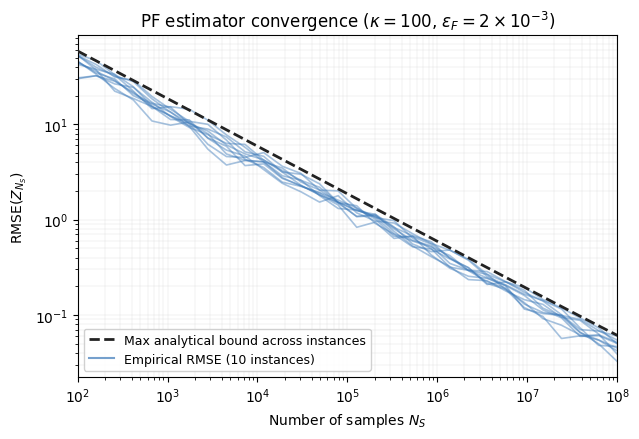

In [4]:
pf100, grid100 = load_grouped(DATA/"convergence"/"pf_kappa100.csv")
bound100 = max_analytical_bound(pf100, grid100)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for g in pf100.values():
    ax.plot(g["N_S"], g["rmse"], color=PF_COLOR, alpha=0.45, linewidth=1.2, zorder=2)
ax.plot(grid100, bound100, color="#222222", linestyle="--", linewidth=2.0, zorder=3,
        label="Max analytical bound across instances")
ax.plot([], [], color=PF_COLOR, alpha=0.7, linewidth=1.5,
        label=f"Empirical RMSE ({len(pf100)} instances)")
_style_axes(ax)
ax.set_xlim(grid100.min(), grid100.max())
ax.set_xlabel(r"Number of samples $N_S$"); ax.set_ylabel(r"RMSE$(Z_{N_S})$")
ax.set_title(r"PF estimator convergence ($\kappa = 100$, $\epsilon_F = 2\times 10^{-3}$)")
ax.legend(loc="lower left", frameon=True, framealpha=0.9, fontsize=9)
fig.tight_layout(); fig.savefig(FIGS/"pf_kappa100_convergence.pdf", dpi=200); plt.show()

## 4. Figure — Fourier-time tail distribution at $\kappa=100$  (`fig:fourier_time_distribution`)

The sampled Fourier time is $\lvert\tau\rvert=\lvert y_j z_k\rvert$ with $(j,k)$ drawn from the
product distribution $p_y\otimes p_z$ stored in each instance's `.npz`. We form the exact
complementary CDF $\mathbb{P}(\lvert\tau\rvert\ge T)$ per instance by enumerating the
$J\times K$ grid of times and their probabilities (no sampling required).

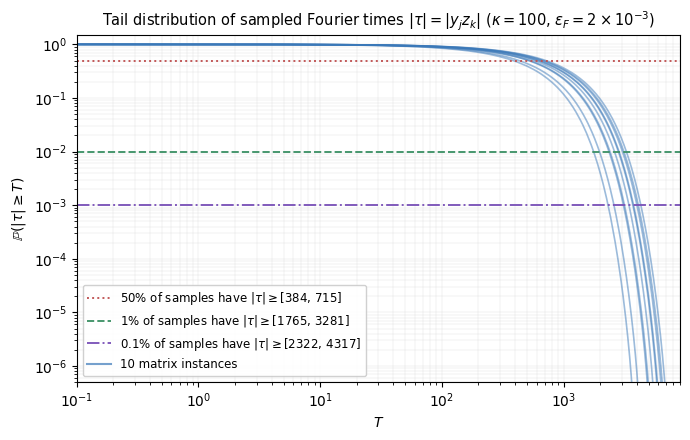

t_max across instances: [3969, 7544]
median |tau| : [384, 715]
1%  quantile : [1765, 3281]
0.1% quantile: [2322, 4317]


In [5]:
def _tau_arrays(npz_path):
    # Return (|tau| sorted, joint prob sorted, t_max, kappa, eps_F).
    d = np.load(npz_path)
    y, z = np.abs(d["y_nodes"]), np.abs(d["z_nodes"])
    tau = np.abs(np.outer(y, z)).ravel()
    p   = np.outer(d["p_y"], d["p_z"]).ravel()
    order = np.argsort(tau)
    return (tau[order], p[order], float(d["t_max"]),
            int(d["kappa"]), float(d["eps_F"]))

def _ccdf(tau_sorted, p_sorted, n_grid=2000):
    # Complementary CDF P(|tau| >= T), subsampled to n_grid points for plotting.
    cdf  = np.cumsum(p_sorted)
    ccdf = 1.0 - cdf + p_sorted
    if len(tau_sorted) > n_grid:
        idx = np.unique(np.linspace(0, len(tau_sorted)-1, n_grid).astype(int))
        return tau_sorted[idx], ccdf[idx]
    return tau_sorted, ccdf

def _quantile(tau_sorted, p_sorted, q):
    # Paper convention: time at cumulative level (1-q), via searchsorted on the CDF.
    cdf = np.cumsum(p_sorted)
    return tau_sorted[np.searchsorted(cdf, 1.0 - q)]

def plot_tau_figure(npz_dir, outfile):
    paths = sorted(Path(npz_dir).glob("instance_*.npz"))
    fig, ax = plt.subplots(figsize=(7, 4.5))
    color_inst = PF_COLOR
    med, p99, p999, t_maxs = [], [], [], []
    kappa = eps_F = None
    for p in paths:
        tau_s, p_s, tmax, kappa, eps_F = _tau_arrays(p)
        T, ccdf = _ccdf(tau_s, p_s)
        ax.plot(T, ccdf, color=color_inst, alpha=0.5, linewidth=1.2)
        med.append(_quantile(tau_s, p_s, 0.5))
        p99.append(_quantile(tau_s, p_s, 0.01))
        p999.append(_quantile(tau_s, p_s, 0.001))
        t_maxs.append(tmax)
    # quantile reference lines: distinct styles AND colors (matching the paper)
    qlines = [
        (0.5,   ":",  "#bf5050", min(med),  max(med),  "50%"),
        (0.01,  "--", "#3d9166", min(p99),  max(p99),  "1%"),
        (0.001, "-.", "#7a52b8", min(p999), max(p999), "0.1%"),
    ]
    for pct, ls, color, lo, hi, lbl in qlines:
        ax.axhline(pct, color=color, linestyle=ls, linewidth=1.4, alpha=0.95,
                   label=fr"{lbl} of samples have $|\tau| \geq [{lo:.0f},\,{hi:.0f}]$")
    ax.plot([], [], color=color_inst, alpha=0.7, linewidth=1.5,
            label=fr"{len(paths)} matrix instances")
    _style_axes(ax)
    ax.set_xlabel(r"$T$"); ax.set_ylabel(r"$\mathbb{P}(|\tau| \geq T)$")
    eps_F_str = r"2 \times 10^{-3}" if abs(eps_F - 2e-3) < 1e-6 else f"{eps_F:g}"
    ax.set_title(rf"Tail distribution of sampled Fourier times "
                 rf"$|\tau| = |y_j z_k|$ "
                 rf"($\kappa = {kappa}$, $\epsilon_F = {eps_F_str}$)", fontsize=10.5)
    ax.set_xlim(1e-1, 1.2*max(t_maxs)); ax.set_ylim(5e-7, 1.5)
    ax.legend(loc="lower left", fontsize=8.5, frameon=True, framealpha=0.92)
    fig.tight_layout(); fig.savefig(outfile, dpi=200, bbox_inches="tight"); plt.show()
    print(f"t_max across instances: [{min(t_maxs):.0f}, {max(t_maxs):.0f}]")
    print(f"median |tau| : [{min(med):.0f}, {max(med):.0f}]")
    print(f"1%  quantile : [{min(p99):.0f}, {max(p99):.0f}]")
    print(f"0.1% quantile: [{min(p999):.0f}, {max(p999):.0f}]")

plot_tau_figure(DATA/"fourier_nodes"/"kappa100", FIGS/"tau_cdf_kappa100.pdf")

## 5. Figure — PF vs RTE convergence at $\kappa=3$  (`fig:pf_rte_comparison`)

The same ten random matrices, now at $\kappa=3$ where both subroutines are classically tractable.
PF uses the adaptive Trotter rule; RTE uses $r_{\rm RTE}(\tau)=\lceil c_{\rm RTE}\tau^2\rceil$ with
$c_{\rm RTE}=1$. Both empirical bundles are shown with their respective max-across-instances bounds.

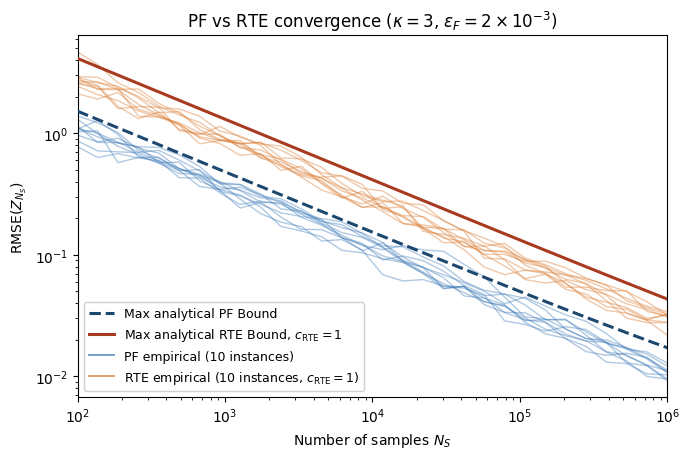

In [6]:
pf3,  grid_pf3  = load_grouped(DATA/"convergence"/"pf_kappa3.csv")
rte3, grid_rte3 = load_grouped(DATA/"convergence"/"rte_kappa3_c1.csv")
c_rte = float(pd.read_csv(DATA/"convergence"/"rte_kappa3_c1.csv")["c_rte"].iloc[0])

# Analytical bounds are closed-form: evaluate on the union of both N_S grids
grid3 = np.array(sorted(set(grid_pf3) | set(grid_rte3)))
pf_bound3  = max_analytical_bound(pf3,  grid3)
rte_bound3 = max_analytical_bound(rte3, grid3)

fig, ax = plt.subplots(figsize=(7.0, 4.7))
for g in pf3.values():
    ax.plot(g["N_S"], g["rmse"], color=PF_COLOR, alpha=0.4, lw=1.0, zorder=2)
for g in rte3.values():
    ax.plot(g["N_S"], g["rmse"], color=RTE_COLOR, alpha=0.4, lw=1.0, zorder=2)
ax.plot(grid3, pf_bound3,  "--", color=PF_BOUND,  lw=2.2, zorder=4,
        label="Max analytical PF Bound")
ax.plot(grid3, rte_bound3, "-",  color=RTE_BOUND, lw=2.2, zorder=4,
        label=fr"Max analytical RTE Bound, $c_{{\rm RTE}}={c_rte:g}$")
ax.plot([], [], color=PF_COLOR,  alpha=0.7, lw=1.4,
        label=f"PF empirical ({len(pf3)} instances)")
ax.plot([], [], color=RTE_COLOR, alpha=0.7, lw=1.4,
        label=fr"RTE empirical ({len(rte3)} instances, $c_{{\rm RTE}}={c_rte:g}$)")
ax.set(xscale="log", yscale="log", xlabel=r"Number of samples $N_S$",
       ylabel=r"RMSE$(Z_{N_S})$",
       title=r"PF vs RTE convergence ($\kappa=3$, $\epsilon_F=2\times10^{-3}$)")
ax.set_xlim(grid3.min(), grid3.max())
ax.legend(loc="lower left", framealpha=0.92, fontsize=9)
fig.tight_layout(); fig.savefig(FIGS/"pf_rte_kappa3_convergence.pdf"); plt.show()

## 6. Figure — Fourier-time tail distribution at $\kappa=3$  (`fig:fourier_time_distribution_kappa3`)

Same construction as §4, at $\kappa=3$. The sampling distribution is a property of the Fourier
series and is identical for the PF and RTE runs on a given matrix.

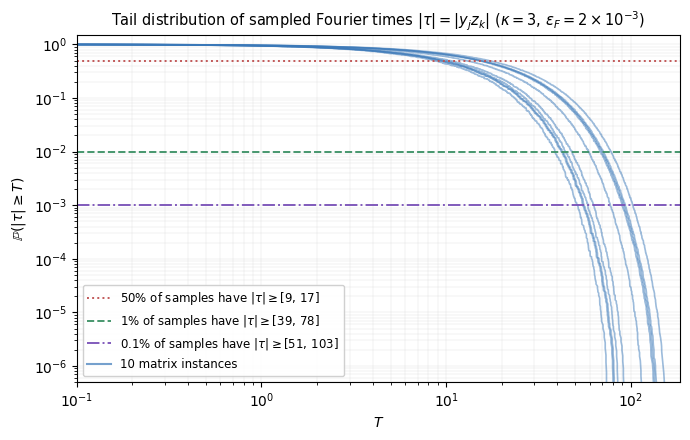

t_max across instances: [74, 154]
median |tau| : [9, 17]
1%  quantile : [39, 78]
0.1% quantile: [51, 103]


In [7]:
plot_tau_figure(DATA/"fourier_nodes"/"kappa3", FIGS/"tau_cdf_kappa3.pdf")

---
All six artifacts written to `figures/`. Re-running the notebook top-to-bottom reproduces the
paper's tables and figures from the published data with no random seed dependence (the analytical
bounds and tail distributions are exact; the empirical RMSE curves are read from the saved runs).